# SM100 GEMM — Navigating the CUDA Memory Hierarchy

This notebook computes **C = A × Bᵀ** for large FP16 matrices on a
simulated NVIDIA Blackwell (SM100) GPU, with
`A : (M, K)`, `B : (N, K)`, and `C : (M, N)`.
We keep `B` in `(N, K)` form throughout, so the contraction is written
as `A @ B.T` rather than the more conventional `(M, K) @ (K, N)`.
We trace every data movement through the full memory hierarchy with
explicit layouts at each stage, then explore three key optimizations.

```
GMEM ── tma_load ──▶ SMEM ── mma ──▶ TMEM ── tcgen05.ld ──▶ RMEM ── copy ──▶ SMEM ── tma_store ──▶ GMEM
```

| Stage | Instruction | Layout |
|---|---|---|
| **GMEM** | — | Row-major |
| **GMEM → SMEM** | `cp.async.bulk.tensor` (TMA load) | Swizzled col-major 128×16 tile |
| **SMEM → TMEM** | `tcgen05.mma` (UMMA) | 2×2 atoms of 64×64×16 per CTA tile |
| **TMEM** | — | Col-major 128×128 accumulator (F32) |
| **TMEM → RMEM** | `tcgen05.ld` | 128 threads × 128 F32 registers |
| **RMEM → SMEM** | `copy` | SW64-swizzled 128×128 staging tensor (models 128×32 epilogue subtiles) |
| **SMEM → GMEM** | `cp.async.bulk.tensor` (TMA store) | Row-major GMEM with matching store swizzle |


In [1]:
import logging
logging.getLogger('matplotlib').setLevel(logging.ERROR)
import numpy as np

In [2]:
from tensor_layouts import *
from tensor_layouts.viz import draw_layout, draw_composite, draw_swizzle, draw_mma_layout, draw_gemm
from tensor_layouts.atoms import MMAAtom
from tensor_layouts.atoms_nv import SM100_64x64x16_F32F16F16_SS

## TensorMap and Algorithms

On real hardware, TMA is configured through a **TensorMap** descriptor
(`CUtensorMap`) that encodes the global tensor's base, shape, strides,
tile dimensions, and SMEM swizzle.

We model only the part of that descriptor that matters for this notebook's
layout story: the **tile shape** and the **SMEM swizzle**.
The global tensor shape and strides are carried separately by the tensors
passed to `tma_load` / `tma_store`, so this dataclass is a minimal stand-in,
not a full software model of `CUtensorMap`.

When no swizzle is specified, TensorMap defaults to `Swizzle(0, 0, 0)`
— the identity — so `tma_load` / `tma_store` can apply the swizzle
unconditionally, just as the hardware does.

Four functions model the hardware operations:

- **`tma_load(desc, ...)`** — `cp.async.bulk.tensor.2d` load: GMEM → SMEM (applies swizzle from descriptor)
- **`tma_store(desc, ...)`** — `cp.async.bulk.tensor.2d` store: SMEM → GMEM (applies swizzle from descriptor)
- **`mma(atom, ..., m_off, n_off, k_off)`** — `tcgen05.mma`: SMEM → TMEM accumulator (sub-tile offsets for multi-atom CTA tiles)
- **`copy(src, dst)`** — element-wise transfer (RMEM → SMEM)


In [3]:
from dataclasses import dataclass, field
from typing import Optional, Tuple


@dataclass
class TensorMap:
    """Simulated CUtensorMap — the TMA descriptor.

    On real hardware this is a 128-byte opaque descriptor created by
    cuTensorMapEncode*.  It tells the TMA engine everything it needs:
    the global tensor's base, shape, strides, the tile box dimensions,
    and the SMEM swizzle mode.

    Here we store just the tile shape and swizzle — enough to drive
    our simulated tma_load / tma_store.
    """
    tile_shape: Tuple[int, int]          # (rows, cols) of the tile box
    smem_swizzle: Swizzle = field(default_factory=lambda: Swizzle(0, 0, 0))

    def __repr__(self):
        sw = f", {self.smem_swizzle}" if self.smem_swizzle != Swizzle(0, 0, 0) else ""
        return f"TensorMap(tile={self.tile_shape[0]}×{self.tile_shape[1]}{sw})"


def tma_load(desc: TensorMap, gmem: Tensor, smem: Tensor,
             tile_row: int, tile_col: int):
    """cp.async.bulk.tensor.2d — TMA load: GMEM → SMEM.

    The TMA engine copies a tile from global memory into shared memory
    autonomously.  Tile shape and swizzle come from the TensorMap
    descriptor — the swizzle is applied to SMEM addresses during the
    copy, just as on real hardware.
    """
    tile_M, tile_N = desc.tile_shape
    smem_layout = compose(desc.smem_swizzle,
                          Layout((tile_M, tile_N), (1, tile_M)))
    target = smem.view(smem_layout)
    for m in range(tile_M):
        for n in range(tile_N):
            target[m, n] = gmem[tile_row + m, tile_col + n]


def tma_store(desc: TensorMap, smem: Tensor, gmem: Tensor,
              tile_row: int, tile_col: int):
    """cp.async.bulk.tensor.2d — TMA store: SMEM → GMEM.

    The swizzle from the descriptor is applied when reading SMEM
    addresses, mirroring the inverse of the load path.
    """
    tile_M, tile_N = desc.tile_shape
    smem_layout = compose(desc.smem_swizzle,
                          Layout((tile_M, tile_N), (1, tile_M)))
    source = smem.view(smem_layout)
    for m in range(tile_M):
        for n in range(tile_N):
            gmem[tile_row + m, tile_col + n] = source[m, n]


def mma(atom: MMAAtom, A: Tensor, B: Tensor, C: Tensor,
        m_off: int = 0, n_off: int = 0, k_off: int = 0):
    """tcgen05.mma — C += A × Bᵀ.   A:(M,K)  B:(N,K)  C:(M,N)

    Operates on a sub-tile of A, B, C selected by offsets, enabling
    multiple MMA atoms to tile across a larger CTA tile.

    We read/write through the Tensor layouts (handling swizzled SMEM
    correctly) and use numpy.matmul for the inner product — this is
    faster than a pure-Python triple loop because the ~10K element
    copies are cheap compared to 65K Python multiply-add iterations.
    """
    M_a, N_a, K_a = atom.shape_mnk
    a = np.array([A[m_off + m, k_off + k]
                  for m in range(M_a) for k in range(K_a)]).reshape(M_a, K_a)
    b = np.array([B[n_off + n, k_off + k]
                  for n in range(N_a) for k in range(K_a)]).reshape(N_a, K_a)
    c = np.array([C[m_off + m, n_off + n]
                  for m in range(M_a) for n in range(N_a)]).reshape(M_a, N_a)
    c += a @ b.T
    for m in range(M_a):
        for n in range(N_a):
            C[m_off + m, n_off + n] = float(c[m, n])


def copy(src: Tensor, dst: Tensor):
    """Element-wise copy between tensors of equal size."""
    assert size(src) == size(dst)
    for i in range(size(dst)):
        dst[i] = src[i]

## Parameters

In [4]:
# MMA atom — smaller than CTA tile, tiled 2×2
mma_atom = SM100_64x64x16_F32F16F16_SS
MMA_M, MMA_N, MMA_K = mma_atom.shape_mnk

# CTA tile — 128×128, composed of 2×2 MMA atoms per K-step
BLK_M, BLK_N, BLK_K = 128, 128, MMA_K
num_mma_m = BLK_M // MMA_M   # 2
num_mma_n = BLK_N // MMA_N   # 2

# TMA descriptors — tile shape + swizzle (like CUtensorMap)
smem_swizzle = Swizzle(3, 0, 3)
# CUTLASS's FP16 row-major epilogue partitions a 128x128 CTA tile into
# 128x32 subtiles and chooses the SW64 / K_SW64 family for SMEM staging.
# The Python model keeps one CTA-sized store for readability but uses the
# same store-side swizzle family.
epi_tile_n = 32
store_smem_swizzle = Swizzle(2, 4, 3)
tma_load_A  = TensorMap(tile_shape=(BLK_M, BLK_K), smem_swizzle=smem_swizzle)
tma_load_B  = TensorMap(tile_shape=(BLK_N, BLK_K), smem_swizzle=smem_swizzle)
tma_store_C = TensorMap(tile_shape=(BLK_M, BLK_N), smem_swizzle=store_smem_swizzle)

# Matrix dimensions
M, N, K = 512, 512, 512
num_ctas_m, num_ctas_n = M // BLK_M, N // BLK_N
num_k_steps = K // BLK_K

print(f"MMA atom : {mma_atom.name}")
print(f"  (MMA_M, MMA_N, MMA_K) = ({MMA_M}, {MMA_N}, {MMA_K})")
print(f"  thr_id  = {mma_atom.thr_id}")
print(f"CTA tile : ({BLK_M}, {BLK_N}, {BLK_K})")
print(f"  MMA tiles per CTA: {num_mma_m}×{num_mma_n} = {num_mma_m * num_mma_n}")
print(f"TMA load A : {tma_load_A}")
print(f"TMA load B : {tma_load_B}")
print(f"Epilogue subtile (helper heuristic): ({BLK_M}, {epi_tile_n}) -> {store_smem_swizzle}")
print(f"TMA store C: {tma_store_C}")
print(f"\nMatrix: {M}×{N}×{K}")
print(f"Grid: {num_ctas_m}×{num_ctas_n} = {num_ctas_m * num_ctas_n} CTAs")
print(f"K-loop: {num_k_steps} steps per CTA")

MMA atom : SM100_64x64x16_F32F16F16_SS
  (MMA_M, MMA_N, MMA_K) = (64, 64, 16)
  thr_id  = 1 : 0
CTA tile : (128, 128, 16)
  MMA tiles per CTA: 2×2 = 4
TMA load A : TensorMap(tile=128×16, Swizzle(3, 0, 3))
TMA load B : TensorMap(tile=128×16, Swizzle(3, 0, 3))
Epilogue subtile (helper heuristic): (128, 32) -> Swizzle(2, 4, 3)
TMA store C: TensorMap(tile=128×128, Swizzle(2, 4, 3))

Matrix: 512×512×512
Grid: 4×4 = 16 CTAs
K-loop: 32 steps per CTA


---
## Stage 1 — GMEM: Global Memory

The source matrices live in HBM with **row-major** layout.

In [5]:
# GMEM layouts: row-major
gmem_A_layout = Layout((M, K), (K, 1))
gmem_B_layout = Layout((N, K), (K, 1))
gmem_C_layout = Layout((M, N), (N, 1))

print(f"A  GMEM: {gmem_A_layout}   {M}×{K} row-major")
print(f"B  GMEM: {gmem_B_layout}   {N}×{K} row-major")
print(f"C  GMEM: {gmem_C_layout}   {M}×{N} row-major")

A  GMEM: (512, 512) : (512, 1)   512×512 row-major
B  GMEM: (512, 512) : (512, 1)   512×512 row-major
C  GMEM: (512, 512) : (512, 1)   512×512 row-major


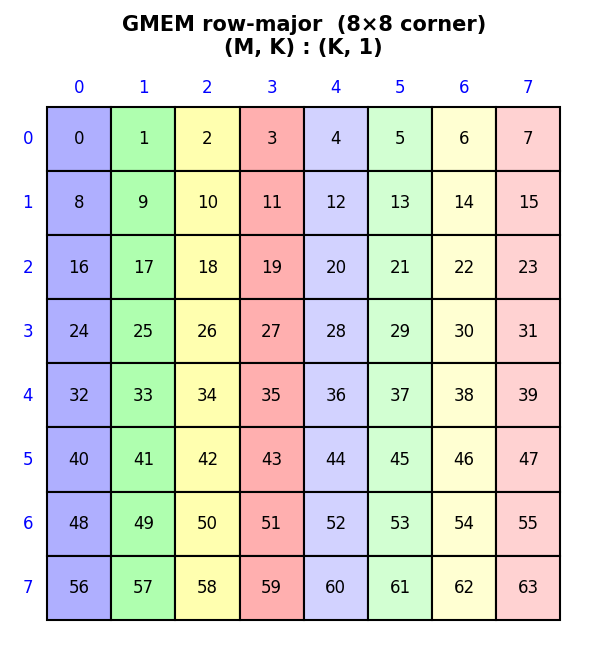

In [6]:
# Visualize GMEM layout pattern (8×8 corner)
draw_layout(
    Layout((8, 8), (8, 1)),
    title='GMEM row-major  (8×8 corner)\n(M, K) : (K, 1)',
    colorize=True)

In [7]:
# Allocate GMEM
A_data = [float((m + k) % 7) for m in range(M) for k in range(K)]
B_data = [float((n * k + 1) % 5) for n in range(N) for k in range(K)]
C_data = [0.0] * (M * N)

A_gmem = Tensor(gmem_A_layout, data=A_data)
B_gmem = Tensor(gmem_B_layout, data=B_data)
C_gmem = Tensor(gmem_C_layout, data=C_data)

print(f"A[0, 0:8] = {[A_gmem[0, k] for k in range(8)]}")
print(f"B[0, 0:8] = {[B_gmem[0, k] for k in range(8)]}")

A[0, 0:8] = [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 0.0]
B[0, 0:8] = [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]


---
## Stage 2 — TMA Load: GMEM → SMEM

The **Tensor Memory Accelerator** copies a `(128, 16)` tile from GMEM
into SMEM per K-step.  The TMA descriptor (TensorMap) encodes the
global tensor layout, tile shape, and SMEM swizzle.  The `tma_load`
function applies the swizzle from the descriptor — matching how the
hardware reads swizzle mode from the `CUtensorMap`.

### SMEM layout: col-major + Swizzle

The SMEM tile is **col-major** `(128, 16):(1, 128)` composed with
`Swizzle(3, 0, 3)`.  The swizzle XORs row-address bits into
column-address bits so adjacent rows land in different memory banks.

In [8]:
# SMEM tile layouts
smem_layout_A = compose(smem_swizzle, Layout((BLK_M, BLK_K), (1, BLK_M)))
smem_layout_B = compose(smem_swizzle, Layout((BLK_N, BLK_K), (1, BLK_N)))

print(f"SMEM A tile:")
print(f"  base    : ({BLK_M}, {BLK_K}) : (1, {BLK_M})   col-major")
print(f"  swizzle : {smem_swizzle}")
print(f"  result  : {smem_layout_A}")
print(f"  cosize  : {cosize(smem_layout_A)}")

SMEM A tile:
  base    : (128, 16) : (1, 128)   col-major
  swizzle : Swizzle(3, 0, 3)
  result  : (Swizzle(3, 0, 3)) o ((128, 16) : (1, 128))
  cosize  : 2048


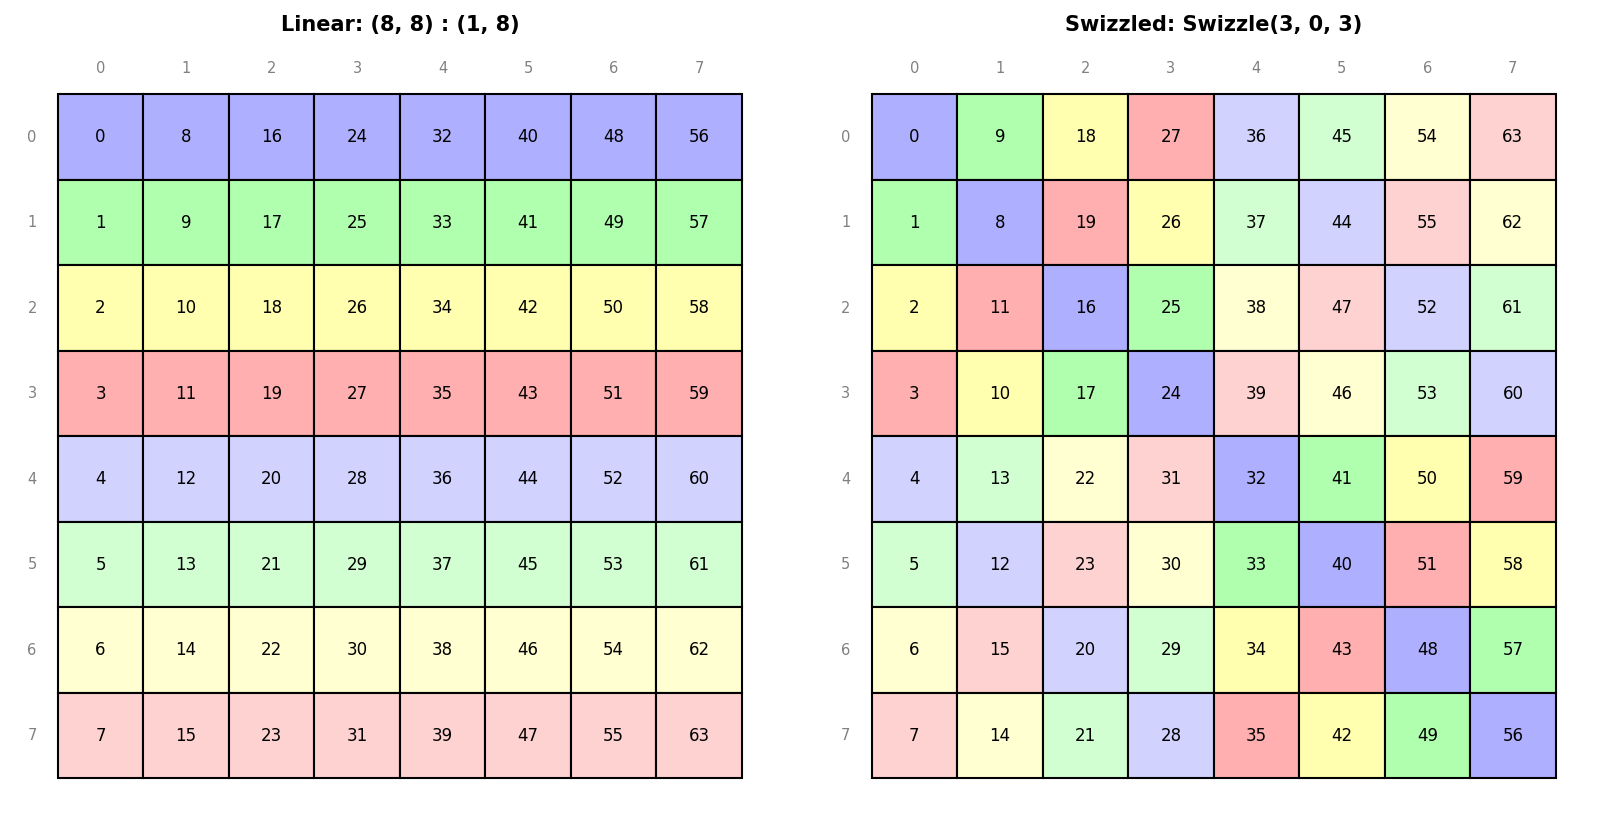

In [9]:
# Visualize the swizzle: linear vs swizzled on 8×8
draw_swizzle(Layout((8, 8), (1, 8)), smem_swizzle, colorize=True)

In [10]:
# Trace TMA load for CTA (0,0), first K-tile
A_smem = Tensor(smem_layout_A, data=[0.0] * cosize(smem_layout_A))
B_smem = Tensor(smem_layout_B, data=[0.0] * cosize(smem_layout_B))

# --- On real hardware: cp.async.bulk.tensor.2d + mbarrier ---
tma_load(tma_load_A, A_gmem, A_smem, tile_row=0, tile_col=0)
tma_load(tma_load_B, B_gmem, B_smem, tile_row=0, tile_col=0)

print(f"TMA load complete: k=[0:{BLK_K})")
print(f"  A_smem[0:4, 0] = {[A_smem[m, 0] for m in range(4)]}")
print(f"  B_smem[0:4, 0] = {[B_smem[n, 0] for n in range(4)]}")
print()

# Verify: swizzle changes addresses, not values
ok = all(A_smem[m, k] == A_gmem[m, k]
         for m in range(BLK_M) for k in range(BLK_K))
print(f"A_smem matches GMEM: {ok}")

TMA load complete: k=[0:16)
  A_smem[0:4, 0] = [0.0, 1.0, 2.0, 3.0]
  B_smem[0:4, 0] = [1.0, 1.0, 1.0, 1.0]

A_smem matches GMEM: True


---
## Stage 3 — tcgen05.mma: SMEM → TMEM

The SM100 **UMMA** instruction reads A and B from SMEM and accumulates
into **Tensor Memory** (TMEM) — on-chip storage between SMEM and
registers.

### UMMA atom layouts

SM100 UMMA operates at the **warp-group** level (128 threads) with
`ThrID = Layout(1)`.  All data is in the value dimension.

Our CTA tile is **128×128**, composed of **2×2 = 4** MMA atoms of
**64×64×16** each.  Each K-step issues 4 `tcgen05.mma` instructions.

In [11]:
print(f"Atom: {mma_atom.name}")
print(f"  (MMA_M, MMA_N, MMA_K) = ({MMA_M}, {MMA_N}, {MMA_K})")
print(f"  thr_id = {mma_atom.thr_id}")
print(f"  A = {mma_atom.a_layout}   ({size(mode(mma_atom.a_layout, 1))} values)")
print(f"  B = {mma_atom.b_layout}   ({size(mode(mma_atom.b_layout, 1))} values)")
print(f"  C = {mma_atom.c_layout}   ({size(mode(mma_atom.c_layout, 1))} values)")
print(f"\nCTA tile: {BLK_M}×{BLK_N} = {num_mma_m}×{num_mma_n} atoms")

Atom: SM100_64x64x16_F32F16F16_SS
  (MMA_M, MMA_N, MMA_K) = (64, 64, 16)
  thr_id = 1 : 0
  A = (1, (64, 16)) : (0, (1, 64))   (1024 values)
  B = (1, (64, 16)) : (0, (1, 64))   (1024 values)
  C = (1, (64, 64)) : (0, (1, 64))   (4096 values)

CTA tile: 128×128 = 2×2 atoms


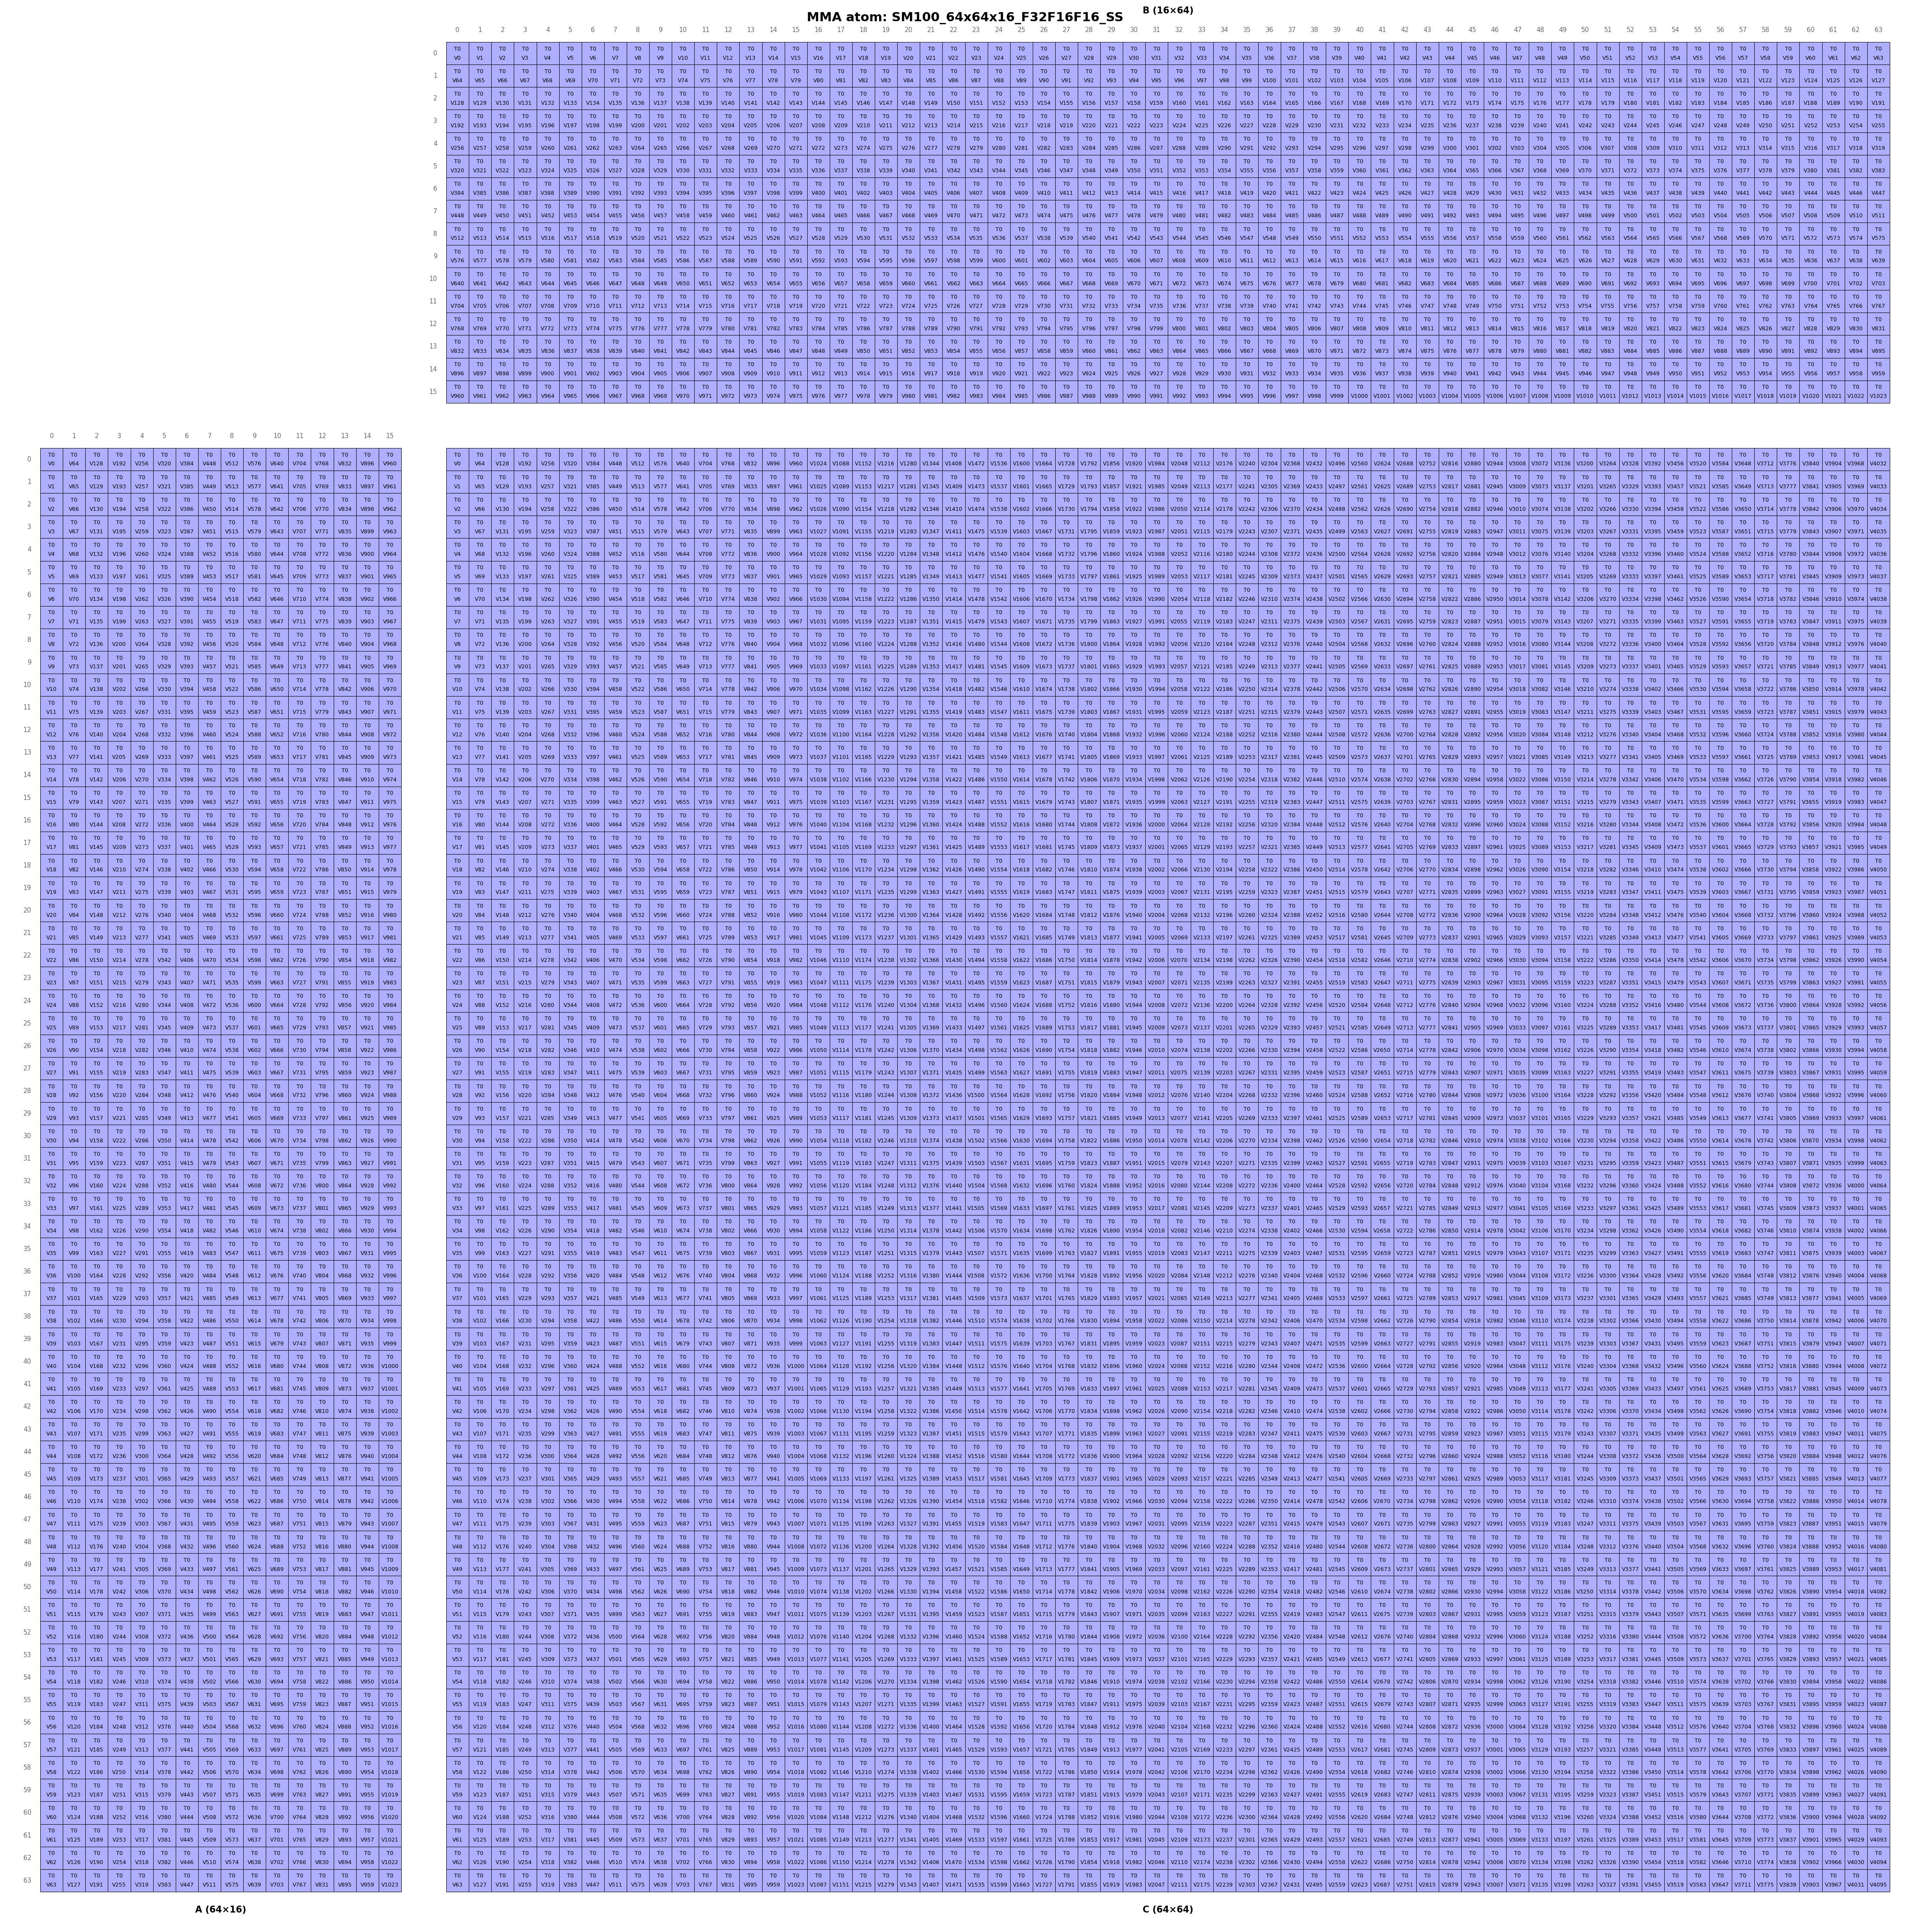

In [12]:
# Visualize atom operand layouts in matmul spatial arrangement
draw_mma_layout(
    mma_atom.a_layout, mma_atom.b_layout, mma_atom.c_layout,
    tile_mnk=mma_atom.shape_mnk,
    thr_id_layout=mma_atom.thr_id,
    main_title=f'MMA atom: {mma_atom.name}',
    colorize=True)

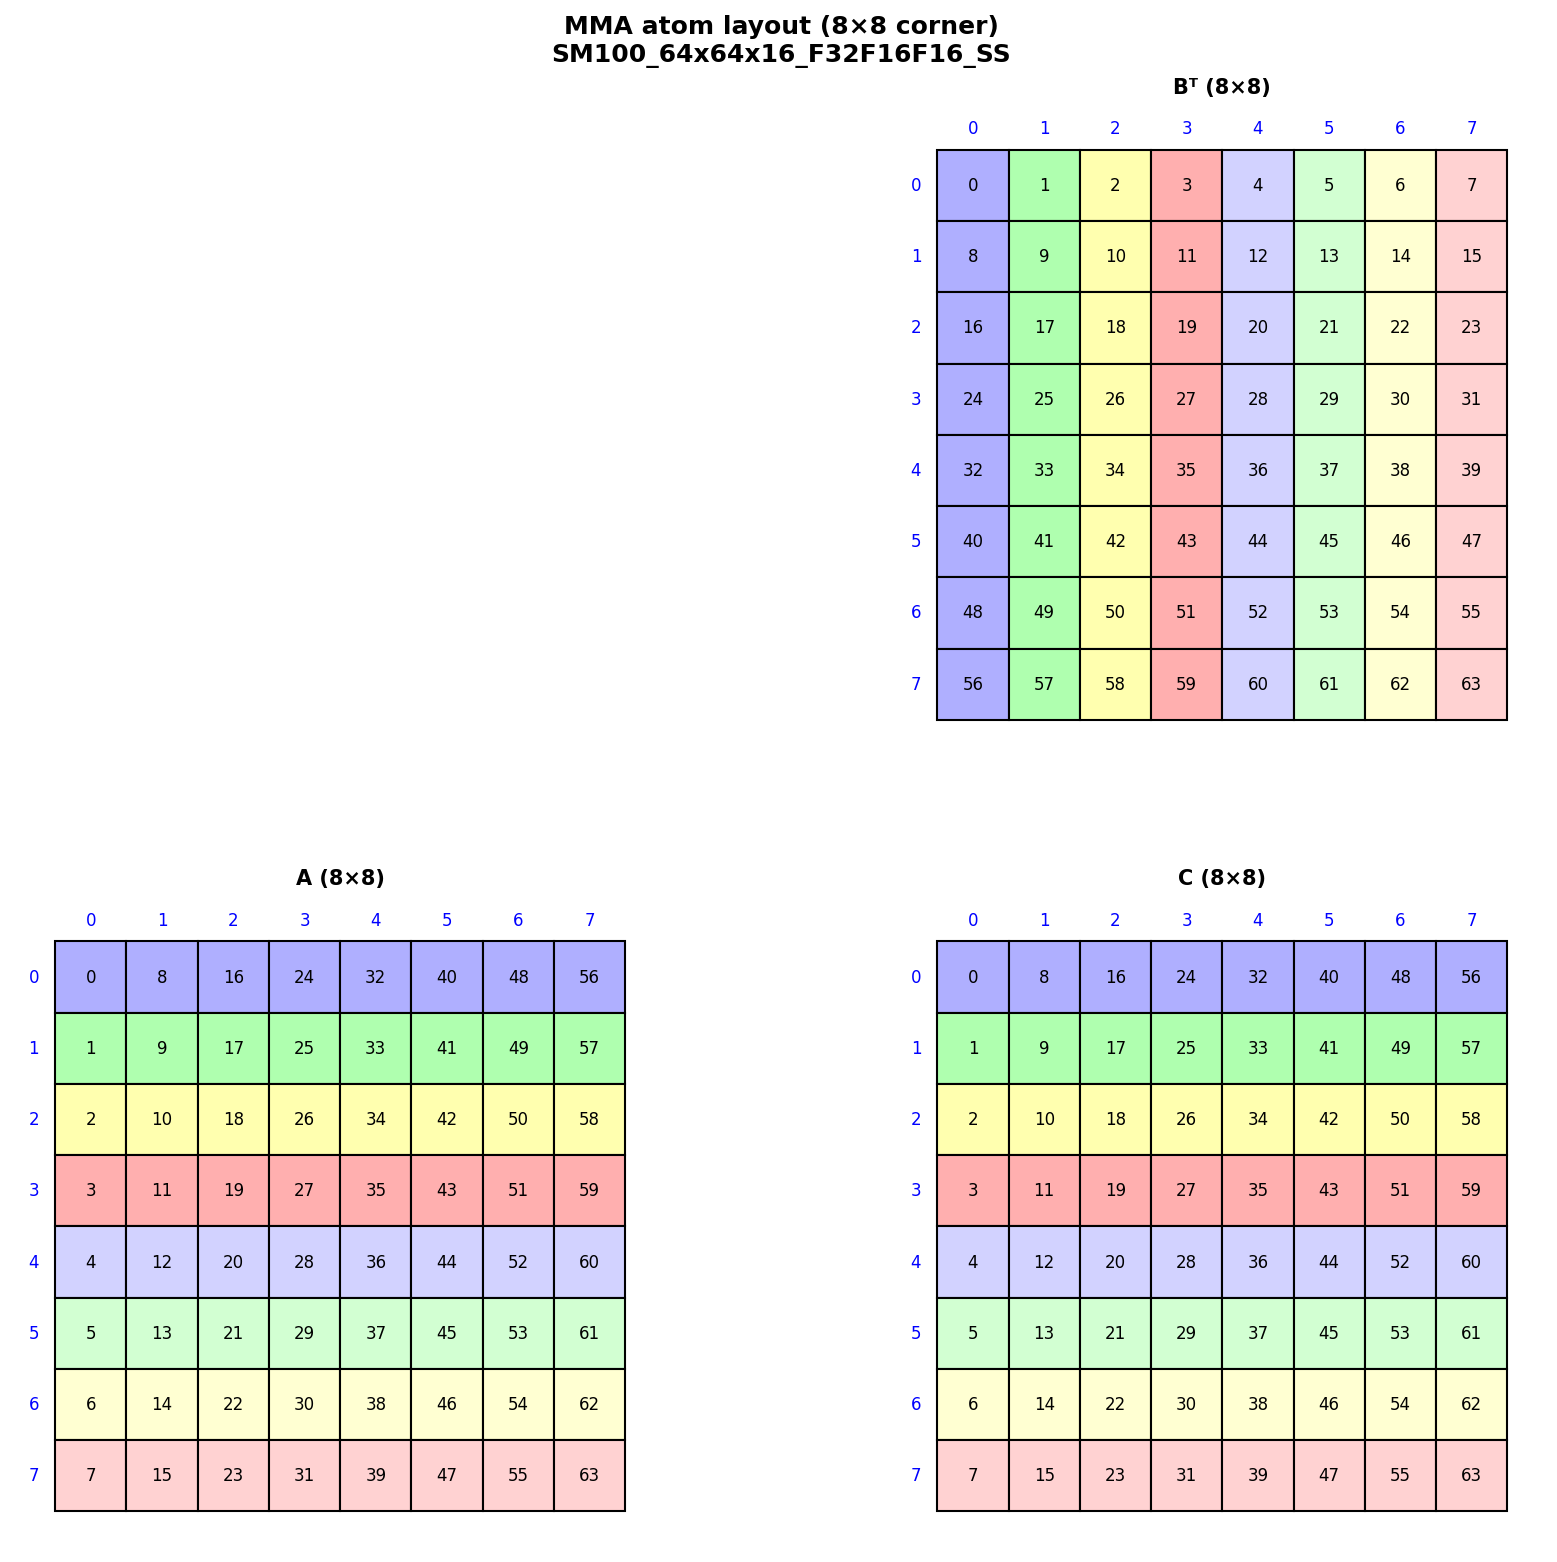

In [13]:
# 8×8 corner — readable view of the col-major pattern above.
# Each cell here corresponds to one cell in the top-left corner
# of the full 64×64 / 64×16 atom panels.
draw_gemm(
    Layout((8, 8), (1, 8)),   # A: col-major (M, K)
    Layout((8, 8), (1, 8)),   # B: col-major (N, K)
    Layout((8, 8), (1, 8)),   # C: col-major (M, N)
    main_title=f'MMA atom layout (8×8 corner)\n{mma_atom.name}',
    colorize=True)

### K-loop: CTA (0, 0)

We trace the full K-loop for one CTA.  Each iteration:
1. **TMA load** — A and B tiles into SMEM (128×16 each)
2. **`tcgen05.mma`** — 2×2 = 4 atom calls, accumulate into TMEM
3. Barrier synchronization (elided in Python)

In [14]:
# Allocate TMEM accumulator — CTA-sized (128×128), not atom-sized
# On real hardware: tcgen05.alloc
tmem_C_layout = Layout((BLK_M, BLK_N), (1, BLK_M))   # col-major
C_tmem = Tensor(tmem_C_layout, data=[0.0] * (BLK_M * BLK_N))

print(f"TMEM accumulator: {tmem_C_layout}  col-major {BLK_M}×{BLK_N}")
print(f"  {BLK_M * BLK_N} F32 values, initialized to zero")

TMEM accumulator: (128, 128) : (1, 128)  col-major 128×128
  16384 F32 values, initialized to zero


In [15]:
# K-loop for CTA (0, 0)
cta_m, cta_n = 0, 0
print(f"CTA ({cta_m}, {cta_n}): K-loop, {num_k_steps} steps")
print(f"  {num_mma_m}×{num_mma_n} = {num_mma_m * num_mma_n} MMA atoms per step")
print()

for k_step in range(num_k_steps):
    k_start = k_step * BLK_K

    # TMA load: GMEM → SMEM
    A_smem = Tensor(smem_layout_A, data=[0.0] * cosize(smem_layout_A))
    B_smem = Tensor(smem_layout_B, data=[0.0] * cosize(smem_layout_B))
    tma_load(tma_load_A, A_gmem, A_smem,
             tile_row=cta_m * BLK_M, tile_col=k_start)
    tma_load(tma_load_B, B_gmem, B_smem,
             tile_row=cta_n * BLK_N, tile_col=k_start)

    # Barrier: mbarrier.arrive + mbarrier.try_wait

    # tcgen05.mma: SMEM → TMEM (2×2 atom tiling)
    for mma_m in range(num_mma_m):
        for mma_n in range(num_mma_n):
            mma(mma_atom, A_smem, B_smem, C_tmem,
                m_off=mma_m * MMA_M, n_off=mma_n * MMA_N)

    if k_step < 3 or k_step >= num_k_steps - 1:
        print(f"  step {k_step:2d}: k=[{k_start}:{k_start+BLK_K})  "
              f"C_tmem[0,0] = {C_tmem[0,0]:.1f}")
    elif k_step == 3:
        print(f"  ...")

print(f"\nK-loop complete.")

CTA (0, 0): K-loop, 32 steps
  2×2 = 4 MMA atoms per step

  step  0: k=[0:16)  C_tmem[0,0] = 43.0


  step  1: k=[16:32)  C_tmem[0,0] = 90.0


  step  2: k=[32:48)  C_tmem[0,0] = 141.0
  ...


  step 31: k=[496:512)  C_tmem[0,0] = 1533.0

K-loop complete.


---
## Stage 4 — tcgen05.ld: TMEM → RMEM

`tcgen05.ld` is the only exit path from TMEM into the register file.
The accumulator is collectively owned by the warp group — a flat 128×128 array
of F32 with no per-thread partitioning before the load.  `tcgen05.ld`
redistributes those 128×128 = 16,384 values across 128 threads, placing
**128 F32 registers per thread** (50% of the SM100 256-register file).

In CuteDSL the corresponding instruction is `Ld32x32bOp(Repetition.x64)` —
32×32-element loads repeated to cover the full tile.

### Subtiled loads

The CuteDSL epilogue splits the load into `subtile_cnt=4` passes, keeping peak
register occupancy at **32 regs/thread per pass** (12.5% of the file).
This leaves headroom for epilogue temporaries — bias, activation,
quantization, and F32→FP16 conversion all happen in registers before the
result is staged back out.

Our Python simulation deliberately elides that register mapping because there is
no register file to pressure.  TMEM and RMEM share backing data, so the Python
code teaches the **stage order** and the **data ownership change**, but not the
exact per-thread register redistribution.


In [16]:
# tcgen05.ld: TMEM → RMEM
rmem_C_layout = tmem_C_layout
C_rmem = C_tmem   # alias in Python

print(f"RMEM C: {rmem_C_layout}  (128 threads × 128 regs on real HW)")

RMEM C: (128, 128) : (1, 128)  (128 threads × 128 regs on real HW)


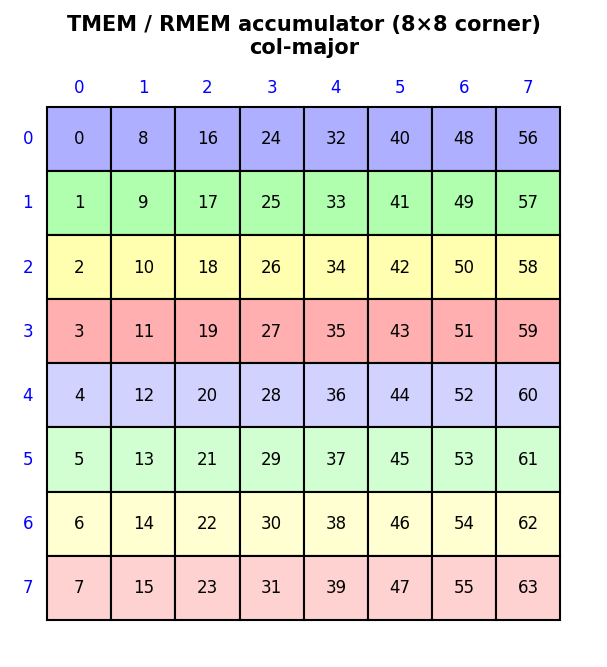

In [17]:
draw_layout(
    Layout((8, 8), (1, 8)),
    title='TMEM / RMEM accumulator (8×8 corner)\ncol-major',
    colorize=True)

In [18]:
# Register budget for the accumulator tile
total_values    = BLK_M * BLK_N            # 128×128 = 16,384 F32 values
threads         = 128                       # warp-group size
regs_per_thread = total_values // threads   # 128 F32 registers
bytes_per_thread = regs_per_thread * 4      # 512 bytes
sm100_reg_limit = 256                       # SM100 register file size

print(f"Accumulator: {BLK_M}×{BLK_N} = {total_values:,} F32 values")
print(f"  {total_values} / {threads} threads = {regs_per_thread} regs/thread ({bytes_per_thread} B)")
print(f"  SM100 register file: {sm100_reg_limit} regs/thread")
print(f"  Accumulator uses {regs_per_thread}/{sm100_reg_limit} = {100*regs_per_thread/sm100_reg_limit:.0f}% of the register file")
print()
subtile_cnt = 4
print(f"Subtiled loading (subtile_cnt={subtile_cnt}):")
print(f"  {regs_per_thread} / {subtile_cnt} = {regs_per_thread // subtile_cnt} regs/pass"
      f" → {100*(regs_per_thread//subtile_cnt)/sm100_reg_limit:.0f}% of the register file per pass")

Accumulator: 128×128 = 16,384 F32 values
  16384 / 128 threads = 128 regs/thread (512 B)
  SM100 register file: 256 regs/thread
  Accumulator uses 128/256 = 50% of the register file

Subtiled loading (subtile_cnt=4):
  128 / 4 = 32 regs/pass → 12% of the register file per pass


---
## Stage 5 — copy: RMEM → SMEM

TMA store reads from SMEM, not the register file, so the epilogue must stage
the accumulator through shared memory before the DMA engine can write GMEM.

In the Blackwell/CUTLASS epilogue used by the CuteDSL kernel, a row-major FP16
`128x128` CTA tile is partitioned into `128x32` epilogue subtiles and
`make_smem_layout_epi(...)` selects the `K_SW64` family, which corresponds to
`Swizzle(2,4,3)`.

The Python model keeps a single CTA-sized `128x128` SMEM tensor instead of
explicitly looping over four `128x32` store subtiles, but it now uses that same
store-side swizzle family so Stages 5 and 6 exercise a swizzled SMEM → GMEM
path instead of an identity layout.

In [19]:
# RMEM → SMEM: copy the 128x128 accumulator into swizzled store staging SMEM
smem_C_layout = compose(store_smem_swizzle, Layout((BLK_M, BLK_N), (1, BLK_M)))
C_smem = Tensor(smem_C_layout, data=[0.0] * cosize(smem_C_layout))

copy(C_rmem, C_smem)
assert all(C_smem[m, n] == C_rmem[m, n] for m in range(BLK_M) for n in range(BLK_N))

print(f"RMEM → SMEM complete")
print(f"  store swizzle = {store_smem_swizzle}")
print(f"  C_smem[0,0] = {C_smem[0,0]:.1f}")

RMEM → SMEM complete
  store swizzle = Swizzle(2, 4, 3)
  C_smem[0,0] = 1533.0


---
## Stage 6 — TMA Store: SMEM → GMEM

UMMA produces a **col-major** accumulator (M contiguous); GMEM `C` is
**row-major** (N contiguous).  The TMA engine handles that layout change during
the bulk copy, so we can read the staged SMEM tile with one layout and write
the destination GMEM tile with another.

For the store to be correct, the descriptor and the staging tensor must agree on
the SMEM swizzle.  Here both use `Swizzle(2,4,3)`, matching the SW64 family the
Blackwell epilogue helper selects for FP16 row-major `128x32` epilogue subtiles.
Python still stores the whole CTA tile in one call, but the SMEM layout it
exercises is no longer the identity path.

**Pipelining:** TMA store is asynchronous — the instruction returns immediately
while the DMA engine works.  In a pipelined kernel the store of CTA tile *t*
overlaps with the mainloop of tile *t + 1*.  CUTLASS models this with a separate
epilogue pipeline stage count.

### Store-Side Swizzle

Before looking at the full SMEM → GMEM transformation, it helps to visualize
`Swizzle(2,4,3)` by itself.  For FP16 this SW64 / `K_SW64` family is most naturally
shown on its canonical atom-level `8x32` base layout.


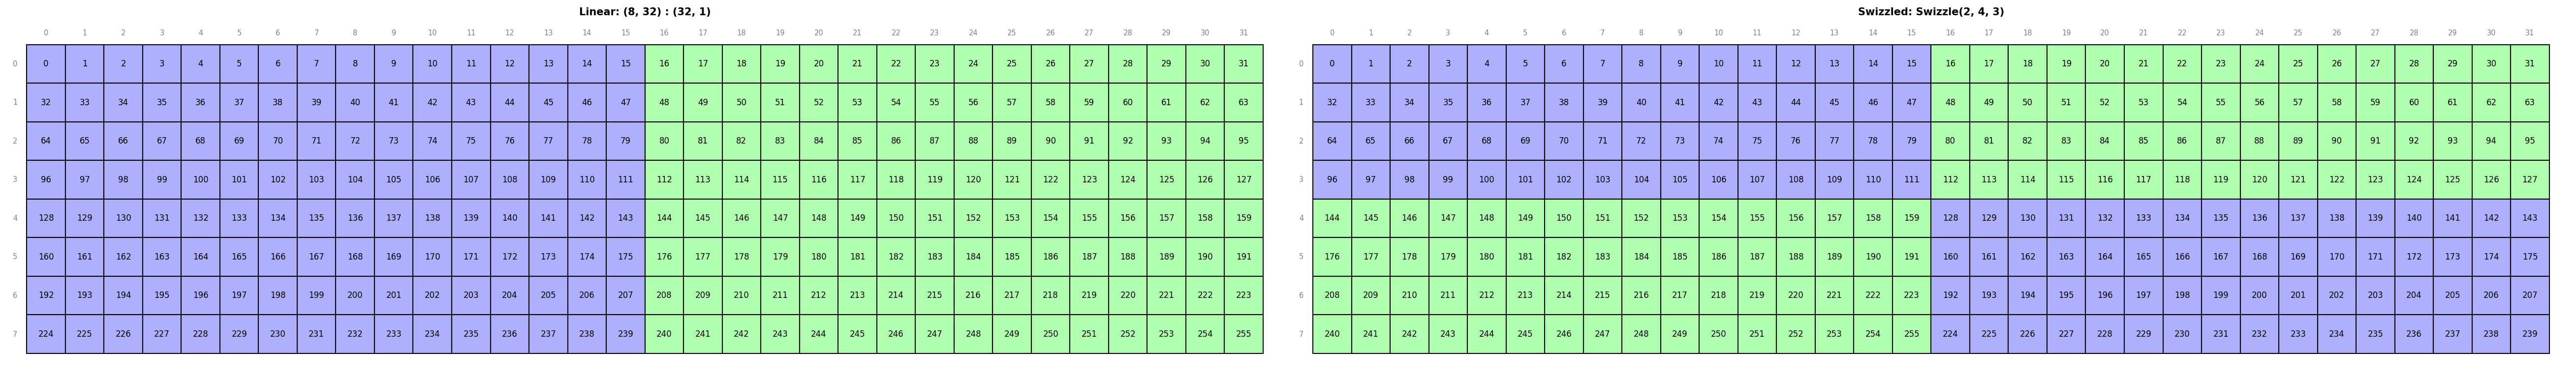

In [20]:
# Visualize the store-side swizzle family on a representative 8x32 atom
draw_swizzle(
    Layout((8, 32), (32, 1)),
    store_smem_swizzle,
    colorize=True,
)


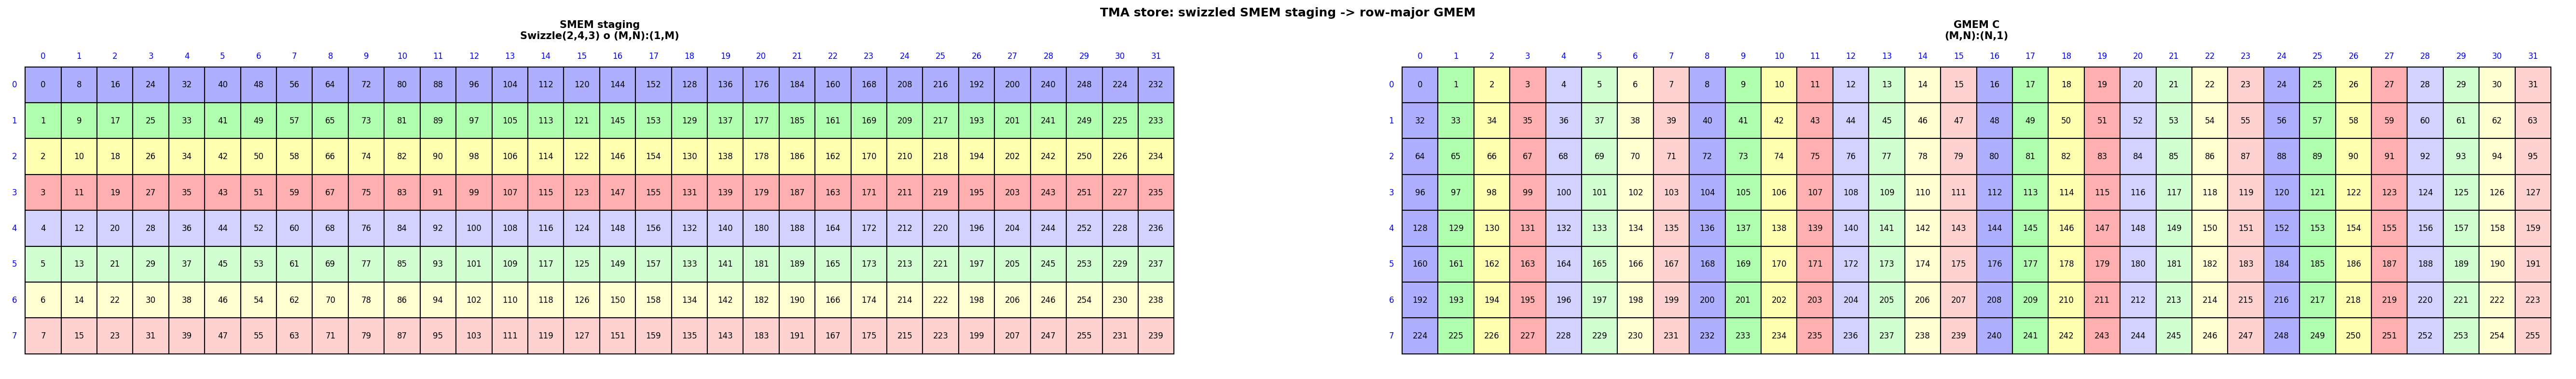

In [21]:
# Visualize a representative store subtile: swizzled SMEM staging -> row-major GMEM
draw_composite(
    [compose(store_smem_swizzle, Layout((8, 32), (1, 8))), Layout((8, 32), (32, 1))],
    titles=['SMEM staging\nSwizzle(2,4,3) o (M,N):(1,M)',
            'GMEM C\n(M,N):(N,1)'],
    main_title='TMA store: swizzled SMEM staging -> row-major GMEM',
    colorize=True)

In [22]:
# TMA store: SMEM → GMEM
tma_store(tma_store_C, C_smem, C_gmem,
          tile_row=cta_m * BLK_M, tile_col=cta_n * BLK_N)

print(f"TMA store: CTA ({cta_m},{cta_n}) → GMEM")
print(f"  C[0,0] = {C_gmem[0, 0]:.1f}")
print(f"  C[0,1] = {C_gmem[0, 1]:.1f}")
print(f"  C[1,0] = {C_gmem[1, 0]:.1f}")

TMA store: CTA (0,0) → GMEM
  C[0,0] = 1533.0
  C[0,1] = 3067.0
  C[1,0] = 1534.0


---
## Full Grid: All CTAs

Run the complete pipeline for all remaining CTAs.

In [23]:
import time
t0 = time.time()

for cm in range(num_ctas_m):
    for cn in range(num_ctas_n):
        if cm == 0 and cn == 0:
            continue  # already computed

        # Allocate TMEM
        C_acc = Tensor(tmem_C_layout, data=[0.0] * (BLK_M * BLK_N))

        # K-loop
        for ks in range(num_k_steps):
            kk = ks * BLK_K
            a_s = Tensor(smem_layout_A, data=[0.0] * cosize(smem_layout_A))
            b_s = Tensor(smem_layout_B, data=[0.0] * cosize(smem_layout_B))
            tma_load(tma_load_A, A_gmem, a_s,
                     tile_row=cm * BLK_M, tile_col=kk)
            tma_load(tma_load_B, B_gmem, b_s,
                     tile_row=cn * BLK_N, tile_col=kk)
            for mma_m in range(num_mma_m):
                for mma_n in range(num_mma_n):
                    mma(mma_atom, a_s, b_s, C_acc,
                        m_off=mma_m * MMA_M, n_off=mma_n * MMA_N)

        # TMEM → RMEM → SMEM → GMEM
        c_s = Tensor(smem_C_layout, data=[0.0] * cosize(smem_C_layout))
        copy(C_acc, c_s)
        tma_store(tma_store_C, c_s, C_gmem,
                  tile_row=cm * BLK_M, tile_col=cn * BLK_N)

    print(f"  Row {cm} complete ({num_ctas_n} CTAs)")

elapsed = time.time() - t0
print(f"\nAll {num_ctas_m * num_ctas_n} CTAs complete in {elapsed:.1f}s")

  Row 0 complete (4 CTAs)


  Row 1 complete (4 CTAs)


  Row 2 complete (4 CTAs)


  Row 3 complete (4 CTAs)

All 16 CTAs complete in 51.5s


---
## Verification

In [24]:
# Reference: numpy matmul
A_np = np.array(A_data).reshape(M, K)
B_np = np.array(B_data).reshape(N, K)
C_ref = A_np @ B_np.T

max_err = max(abs(C_gmem[m, n] - C_ref[m, n])
              for m in range(M) for n in range(N))

print(f"Max error: {max_err:.6e}")
print(f"Result: {'PASS' if max_err < 1e-1 else 'FAIL'}")
print()
for i in range(4):
    print(f"  C[{i},0] = {C_gmem[i,0]:10.1f}  (ref: {C_ref[i,0]:10.1f})")

Max error: 0.000000e+00
Result: PASS

  C[0,0] =     1533.0  (ref:     1533.0)
  C[1,0] =     1534.0  (ref:     1534.0)
  C[2,0] =     1535.0  (ref:     1535.0)
  C[3,0] =     1536.0  (ref:     1536.0)


---
## Optimization 1: Tile Reuse

In the naive grid loop above, every CTA independently loads its A and B
tiles from GMEM.  But CTAs in the same **row** of the grid share the
same A tile rows, and CTAs in the same **column** share the same B tile
rows.

For a 4×4 grid with K-step `k`:
- CTA `(m, 0)` and CTA `(m, 3)` both load `A[m*128:(m+1)*128, k*16:(k+1)*16]`
- CTA `(0, n)` and CTA `(2, n)` both load `B[n*128:(n+1)*128, k*16:(k+1)*16]`

On real hardware, the GPU exploits this through:
- **L2 cache**: tiles loaded by one CTA are cached for neighbors
- **TMA multicast**: a single TMA load can deliver to multiple SMs
- **Cluster-level SMEM**: SM90+ clusters let CTAs on the same GPC
  access each other's shared memory directly

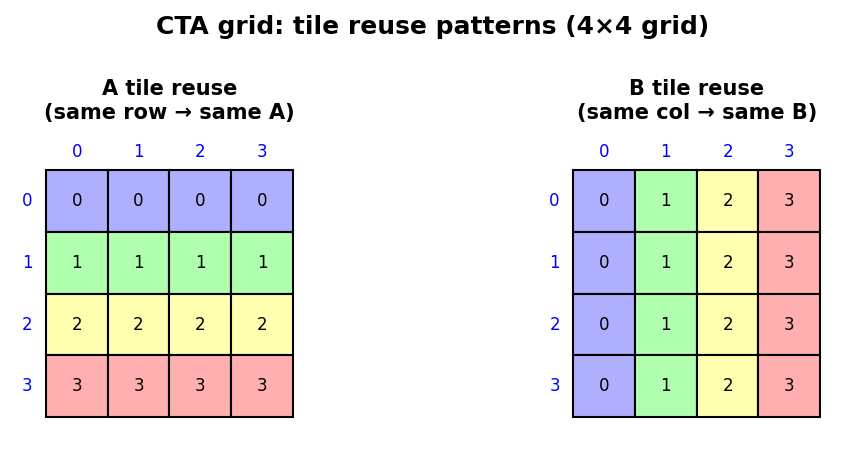

In [25]:
# Visualize tile reuse pattern for a 4×4 grid
# Color by which A-row (mode 0) or B-column (mode 1) each CTA uses
grid_A_reuse = Layout((4, 4), (1, 0))   # same color per row = shared A
grid_B_reuse = Layout((4, 4), (0, 1))   # same color per col = shared B

draw_composite(
    [(grid_A_reuse, {"colorize": True}),
     (grid_B_reuse, {"colorize": True})],
    titles=['A tile reuse\n(same row → same A)',
            'B tile reuse\n(same col → same B)'],
    main_title='CTA grid: tile reuse patterns (4×4 grid)',
    colorize=True)

---
## Optimization 2: Double-Buffering in SMEM

In the naive K-loop, TMA and MMA execute sequentially: load tile `k`,
wait, compute, load tile `k+1`, wait, compute, ...  This wastes the
MMA units while TMA is working and vice versa.

**Double-buffering** pipelines the two: while MMA computes on buffer 0,
TMA prefetches the next tile into buffer 1.  The buffers alternate
each iteration (ping-pong).

The Python code below is still a **serial simulation**.
It models buffer ownership and dependency order, not true overlap or timing.
The CuteDSL kernel later uses `PipelineTmaUmma` to express the real
asynchronous pipeline on hardware.

```
step 0:  TMA → buf[0]       MMA idle
step 1:  TMA → buf[1]       MMA ← buf[0]
step 2:  TMA → buf[0]       MMA ← buf[1]
step 3:  TMA → buf[1]       MMA ← buf[0]
  ...       ...                 ...
step N:  TMA idle            MMA ← buf[(N-1)%2]
```


In [26]:
# Double-buffered K-loop for CTA (0, 0)
C_db = Tensor(tmem_C_layout, data=[0.0] * (BLK_M * BLK_N))

# Two SMEM buffers per operand
A_buf = [Tensor(smem_layout_A, data=[0.0] * cosize(smem_layout_A)) for _ in range(2)]
B_buf = [Tensor(smem_layout_B, data=[0.0] * cosize(smem_layout_B)) for _ in range(2)]

cm, cn = 0, 0

# Prologue: prefetch first tile into buf[0]
tma_load(tma_load_A, A_gmem, A_buf[0],
         tile_row=cm * BLK_M, tile_col=0)
tma_load(tma_load_B, B_gmem, B_buf[0],
         tile_row=cn * BLK_N, tile_col=0)

for k_step in range(num_k_steps):
    curr = k_step % 2
    nxt = (k_step + 1) % 2

    # Prefetch next tile (if not last step)
    if k_step + 1 < num_k_steps:
        k_next = (k_step + 1) * BLK_K
        A_buf[nxt] = Tensor(smem_layout_A, data=[0.0] * cosize(smem_layout_A))
        B_buf[nxt] = Tensor(smem_layout_B, data=[0.0] * cosize(smem_layout_B))
        tma_load(tma_load_A, A_gmem, A_buf[nxt],
                 tile_row=cm * BLK_M, tile_col=k_next)
        tma_load(tma_load_B, B_gmem, B_buf[nxt],
                 tile_row=cn * BLK_N, tile_col=k_next)

    # Barrier: wait for buf[curr]

    # MMA on current buffer (2×2 atom tiling)
    for mma_m in range(num_mma_m):
        for mma_n in range(num_mma_n):
            mma(mma_atom, A_buf[curr], B_buf[curr], C_db,
                m_off=mma_m * MMA_M, n_off=mma_n * MMA_N)

    if k_step < 2 or k_step >= num_k_steps - 1:
        print(f"  step {k_step:2d}: mma ← buf[{curr}], "
              f"tma → buf[{nxt}]{'  (prefetch)' if k_step + 1 < num_k_steps else '  (done)'}")
    elif k_step == 2:
        print(f"  ...")

# Verify matches single-buffer result
match = all(abs(C_db[m, n] - C_tmem[m, n]) < 1e-6
            for m in range(BLK_M) for n in range(BLK_N))
print(f"\nDouble-buffer matches single-buffer: {match}")

  step  0: mma ← buf[0], tma → buf[1]  (prefetch)
  step  1: mma ← buf[1], tma → buf[0]  (prefetch)
  ...


  step 31: mma ← buf[1], tma → buf[0]  (done)

Double-buffer matches single-buffer: True


---
## Optimization 3: 2-CTA Cooperation (Cluster)

On SM90+, the GPU can schedule **clusters** of CTAs on adjacent SMs
that share access to each other's SMEM via `distributed shared memory`.

Two CTAs in a cluster can split the work: CTA0 computes
`C[0:128, 0:128]` and CTA1 computes `C[0:128, 128:256]`.  Both
need the same A tile (same M-rows) but different B tiles.  With
cluster SMEM, CTA0 loads A once and CTA1 reads it directly from
CTA0's SMEM — halving the A bandwidth from GMEM.

In [27]:
# 2-CTA cluster: CTA(0,0) and CTA(0,1) share A tiles
C_cta0 = Tensor(tmem_C_layout, data=[0.0] * (BLK_M * BLK_N))
C_cta1 = Tensor(tmem_C_layout, data=[0.0] * (BLK_M * BLK_N))

for k_step in range(num_k_steps):
    k_start = k_step * BLK_K

    # CTA0 loads A — CTA1 reads from CTA0's SMEM (cluster access)
    A_shared = Tensor(smem_layout_A, data=[0.0] * cosize(smem_layout_A))
    tma_load(tma_load_A, A_gmem, A_shared,
             tile_row=0, tile_col=k_start)

    # Each CTA loads its own B tile
    B0 = Tensor(smem_layout_B, data=[0.0] * cosize(smem_layout_B))
    B1 = Tensor(smem_layout_B, data=[0.0] * cosize(smem_layout_B))
    tma_load(tma_load_B, B_gmem, B0,
             tile_row=0 * BLK_N, tile_col=k_start)
    tma_load(tma_load_B, B_gmem, B1,
             tile_row=1 * BLK_N, tile_col=k_start)

    # Both CTAs use the SAME A_shared tile (2×2 atom tiling)
    for mma_m in range(num_mma_m):
        for mma_n in range(num_mma_n):
            mma(mma_atom, A_shared, B0, C_cta0,
                m_off=mma_m * MMA_M, n_off=mma_n * MMA_N)
            mma(mma_atom, A_shared, B1, C_cta1,
                m_off=mma_m * MMA_M, n_off=mma_n * MMA_N)

# Verify against C_gmem
ok0 = all(abs(C_cta0[m, n] - C_gmem[m, n]) < 1e-1
          for m in range(BLK_M) for n in range(BLK_N))
ok1 = all(abs(C_cta1[m, n] - C_gmem[m, BLK_N + n]) < 1e-1
          for m in range(BLK_M) for n in range(BLK_N))
print(f"2-CTA cluster:")
print(f"  CTA(0,0) matches: {ok0}")
print(f"  CTA(0,1) matches: {ok1}")
print(f"  A tiles loaded: {num_k_steps}  (shared, not {num_k_steps * 2})")

2-CTA cluster:
  CTA(0,0) matches: True
  CTA(0,1) matches: True
  A tiles loaded: 32  (shared, not 64)


---
## Layout Summary

In [28]:
print(f"SM100 GEMM — Layout Chain")
print(f"{'='*60}")
print()
print(f"GMEM   A : {gmem_A_layout}")
print(f"       B : {gmem_B_layout}")
print(f"       C : {gmem_C_layout}")
print(f"  │")
print(f"  │ tma_load  {tma_load_A}")
print(f"  ▼")
print(f"SMEM   A : {smem_layout_A}")
print(f"       B : {smem_layout_B}")
print(f"  │")
print(f"  │ mma  ({mma_atom.name})")
print(f"  │      {num_mma_m}×{num_mma_n} atoms per CTA tile")
print(f"  ▼")
print(f"TMEM   C : {tmem_C_layout}  ({BLK_M*BLK_N} F32)")
print(f"  │")
print(f"  │ tcgen05.ld  → 128 threads × 128 regs")
print(f"  ▼")
print(f"RMEM   C : {rmem_C_layout}")
print(f"  │")
print(f"  │ copy  RMEM → SMEM")
print(f"  ▼")
print(f"SMEM   C : {smem_C_layout}")
print(f"  │")
print(f"  │ tma_store  {tma_store_C}")
print(f"  ▼")
print(f"GMEM   C : {gmem_C_layout}")

SM100 GEMM — Layout Chain

GMEM   A : (512, 512) : (512, 1)
       B : (512, 512) : (512, 1)
       C : (512, 512) : (512, 1)
  │
  │ tma_load  TensorMap(tile=128×16, Swizzle(3, 0, 3))
  ▼
SMEM   A : (Swizzle(3, 0, 3)) o ((128, 16) : (1, 128))
       B : (Swizzle(3, 0, 3)) o ((128, 16) : (1, 128))
  │
  │ mma  (SM100_64x64x16_F32F16F16_SS)
  │      2×2 atoms per CTA tile
  ▼
TMEM   C : (128, 128) : (1, 128)  (16384 F32)
  │
  │ tcgen05.ld  → 128 threads × 128 regs
  ▼
RMEM   C : (128, 128) : (1, 128)
  │
  │ copy  RMEM → SMEM
  ▼
SMEM   C : (Swizzle(2, 4, 3)) o ((128, 128) : (1, 128))
  │
  │ tma_store  TensorMap(tile=128×128, Swizzle(2, 4, 3))
  ▼
GMEM   C : (512, 512) : (512, 1)


---
## CuteDSL Equivalent

Below is a complete CuteDSL GEMM kernel for the **same worked example** as the
Python walk-through.

It matches the same mathematical problem and CTA tile:

- `A : (M, K)`, `B : (N, K)`, `C : (M, N)` with `C = A @ B.T`
- CTA tile `128×128×16`
- `CtaGroup.ONE`
- full epilogue `TMEM → RMEM → SMEM → TMA store → GMEM`

The correspondence is now exact at the worked-example level:

| Stage | Python simulation | CuteDSL |
|---|---|---|
| **Math** | `A:(M,K)`, `B:(N,K)`, `C = A @ B.T` | same |
| **CTA tile** | `128×128×16` | `128×128×16` |
| **TMA descriptor** | `TensorMap(tile, swizzle)` | `make_tiled_tma_atom_A/B(...)` and `make_tiled_tma_atom(S2GOp, ...)` |
| **SMEM A/B** | `compose(Swizzle(3,0,3), Layout(...))` | `make_smem_layout_a/b(...)` |
| **SMEM C (epilogue)** | `compose(Swizzle(2,4,3), Layout(...))` | `make_smem_layout_epi(...)` |
| **TMA load** | `tma_load(desc, gmem, smem, ...)` | `cute.copy(tma_atom, g_tile, s_tile, tma_bar_ptr=...)` |
| **MMA** | 2×2 tiling of `SM100_64x64x16` | `make_trivial_tiled_mma(..., (128,128))` |
| **TMEM → RMEM** | aliased in Python | `tcgen05.make_tmem_copy(...)` + `cute.copy(...)` |
| **RMEM → SMEM** | `copy(C_rmem, C_smem)` | `cute.make_tiled_copy_D(...)` + `cute.copy(...)` |
| **TMA store** | `tma_store(desc, smem, gmem, ...)` | `cute.copy(tma_atom_c, sC, gC)` |
| **Software pipeline** | conceptual ping-pong / double-buffering | `PipelineTmaUmma` with `ab_stages=4` |

The main remaining simplification is Stage 4 on the Python side: Python aliases
TMEM and RMEM because it has no register file.  Stages 5–6 now stage through
swizzled `C` SMEM as the CuteDSL kernel does, but Python still collapses the
four `128x32` epilogue subtiles into one CTA-sized buffer for readability.


In [29]:
# ---------------------------------------------------------------------------
# CuteDSL SM100 GEMM — worked example matching the Python walk-through
#
# Same contraction:
#   A : (M, K)
#   B : (N, K)
#   C : (M, N) = A @ B.T
#
# Same CTA tile:
#   BLK_M = 128, BLK_N = 128, BLK_K = 16
#
# Same full epilogue path:
#   TMEM -> RMEM -> SMEM -> TMA store -> GMEM
# ---------------------------------------------------------------------------

import torch
import cutlass
import cutlass.cute as cute
import cutlass.utils as utils
import cutlass.pipeline as pipeline
from cutlass.cute.nvgpu import cpasync, tcgen05
import cutlass.utils.blackwell_helpers as sm100_utils
from cutlass.cute.runtime import from_dlpack
from cutlass.utils.layout import LayoutEnum

io_dtype = cutlass.Float16
acc_dtype = cutlass.Float32
threads_per_cta = 128

mma_tiler_mnk = (128, 128, 16)
ab_stages = 4
acc_stage = 1
num_c_stage = 1
c_layout_enum = LayoutEnum.ROW_MAJOR

@cute.struct
class SharedStorage:
    ab_mbar_ptr: cute.struct.MemRange[cutlass.Int64, ab_stages * 2]
    acc_mbar_ptr: cute.struct.MemRange[cutlass.Int64, acc_stage * 2]
    tmem_holding_buf: cutlass.Int32

@cute.kernel
def gemm_kernel(
    tiled_mma: cute.TiledMma,
    tma_atom_a: cute.CopyAtom,
    mA_mkl: cute.Tensor,
    tma_atom_b: cute.CopyAtom,
    mB_nkl: cute.Tensor,
    tma_atom_c: cute.CopyAtom,
    mC_mnl: cute.Tensor,
    a_smem_layout: cute.ComposedLayout,
    b_smem_layout: cute.ComposedLayout,
    c_smem_layout: cute.ComposedLayout,
    epi_tile: cute.Tile,
):
    tidx, _, _ = cute.arch.thread_idx()
    warp_idx = cute.arch.warp_idx()
    warp_idx = cute.arch.make_warp_uniform(warp_idx)
    bidx, bidy, _ = cute.arch.block_idx()
    mma_coord_mnk = (bidx, bidy, None)

    # Stage 1 / 2 setup: allocate shared-memory staging buffers.
    smem = utils.SmemAllocator()
    storage = smem.allocate(SharedStorage)
    sA = smem.allocate_tensor(
        element_type=io_dtype,
        layout=a_smem_layout.outer,
        byte_alignment=128,
        swizzle=a_smem_layout.inner,
    )
    sB = smem.allocate_tensor(
        element_type=io_dtype,
        layout=b_smem_layout.outer,
        byte_alignment=128,
        swizzle=b_smem_layout.inner,
    )
    sC = smem.allocate_tensor(
        element_type=io_dtype,
        layout=c_smem_layout.outer,
        byte_alignment=128,
        swizzle=c_smem_layout.inner,
    )

    # Stage 3 setup: allocate CTA-sized accumulator storage in TMEM.
    tmem_alloc_barrier = pipeline.NamedBarrier(
        barrier_id=1,
        num_threads=threads_per_cta,
    )
    tmem = utils.TmemAllocator(
        storage.tmem_holding_buf,
        barrier_for_retrieve=tmem_alloc_barrier,
    )
    num_tmem_cols = 256  # 128x128 F32 accumulator tile
    tmem.allocate(num_tmem_cols)

    if warp_idx == 0:
        cpasync.prefetch_descriptor(tma_atom_a)
        cpasync.prefetch_descriptor(tma_atom_b)
        cpasync.prefetch_descriptor(tma_atom_c)

    num_tma_copy_bytes = (
        cute.size_in_bytes(io_dtype, cute.select(a_smem_layout, mode=[0, 1, 2]))
        + cute.size_in_bytes(io_dtype, cute.select(b_smem_layout, mode=[0, 1, 2]))
    )
    ab_producer, ab_consumer = pipeline.PipelineTmaUmma.create(
        num_stages=ab_stages,
        producer_group=pipeline.CooperativeGroup(pipeline.Agent.Thread),
        consumer_group=pipeline.CooperativeGroup(pipeline.Agent.Thread),
        tx_count=num_tma_copy_bytes,
        barrier_storage=storage.ab_mbar_ptr.data_ptr(),
    ).make_participants()
    acc_producer, acc_consumer = pipeline.PipelineUmmaAsync.create(
        num_stages=acc_stage,
        producer_group=pipeline.CooperativeGroup(pipeline.Agent.Thread),
        consumer_group=pipeline.CooperativeGroup(
            pipeline.Agent.Thread,
            threads_per_cta,
        ),
        barrier_storage=storage.acc_mbar_ptr.data_ptr(),
    ).make_participants()
    c_pipeline = pipeline.PipelineTmaStore.create(
        num_stages=num_c_stage,
        producer_group=pipeline.CooperativeGroup(
            pipeline.Agent.Thread,
            threads_per_cta,
        ),
    )

    gA = cute.local_tile(mA_mkl, mma_tiler_mnk, mma_coord_mnk, proj=(1, None, 1))
    gB = cute.local_tile(mB_nkl, mma_tiler_mnk, mma_coord_mnk, proj=(None, 1, 1))
    gC = cute.local_tile(mC_mnl, mma_tiler_mnk, mma_coord_mnk, proj=(1, 1, None))

    thr_mma = tiled_mma.get_slice(0)
    tCgA = thr_mma.partition_A(gA)
    tCgB = thr_mma.partition_B(gB)
    tCgC = thr_mma.partition_C(gC)
    tCrA = tiled_mma.make_fragment_A(sA)
    tCrB = tiled_mma.make_fragment_B(sB)
    acc_shape = tiled_mma.partition_shape_C(mma_tiler_mnk[:2])
    tCtAcc = tiled_mma.make_fragment_C(acc_shape)

    tAsA, tAgA = cpasync.tma_partition(
        tma_atom_a,
        0,
        cute.make_layout(1),
        cute.group_modes(sA, 0, 3),
        cute.group_modes(tCgA, 0, 3),
    )
    tBsB, tBgB = cpasync.tma_partition(
        tma_atom_b,
        0,
        cute.make_layout(1),
        cute.group_modes(sB, 0, 3),
        cute.group_modes(tCgB, 0, 3),
    )

    tmem.wait_for_alloc()
    tmem_ptr = tmem.retrieve_ptr(acc_dtype)
    tCtAcc = cute.make_tensor(tmem_ptr, tCtAcc.layout)

    # Stages 4–6: build the real TMEM -> RMEM -> SMEM -> TMA-store epilogue.
    copy_atom_t2r = sm100_utils.get_tmem_load_op(
        mma_tiler_mnk,
        c_layout_enum,
        io_dtype,
        acc_dtype,
        epi_tile,
        False,
    )
    tAcc_epi = cute.flat_divide(tCtAcc[((None, None), 0, 0)], epi_tile)
    tiled_copy_t2r = tcgen05.make_tmem_copy(
        copy_atom_t2r,
        tAcc_epi[(None, None, 0, 0)],
    )
    thr_copy_t2r = tiled_copy_t2r.get_slice(tidx)
    tTR_tAcc = thr_copy_t2r.partition_S(tAcc_epi)
    tTR_tAcc = cute.group_modes(tTR_tAcc, 3, cute.rank(tTR_tAcc))

    tCgC_epi = cute.flat_divide(tCgC[((None, None), 0, 0)], epi_tile)
    tTR_gC = thr_copy_t2r.partition_D(tCgC_epi)
    tTR_rAcc = cute.make_rmem_tensor(
        tTR_gC[(None, None, None, 0, 0)].shape,
        acc_dtype,
    )
    tTR_rC = cute.make_rmem_tensor(tTR_rAcc.shape, io_dtype)

    copy_atom_r2s = sm100_utils.get_smem_store_op(
        c_layout_enum,
        io_dtype,
        acc_dtype,
        tiled_copy_t2r,
    )
    tiled_copy_r2s = cute.make_tiled_copy_D(copy_atom_r2s, tiled_copy_t2r)
    thr_copy_r2s = tiled_copy_r2s.get_slice(tidx)
    tRS_sC = thr_copy_r2s.partition_D(sC)
    tRS_rC = tiled_copy_r2s.retile(tTR_rC)

    bSG_sC, bSG_gC = cpasync.tma_partition(
        tma_atom_c,
        0,
        cute.make_layout(1),
        cute.group_modes(sC, 0, 2),
        cute.group_modes(tCgC_epi, 0, 2),
    )
    bSG_gC = cute.group_modes(bSG_gC, 1, cute.rank(bSG_gC))

    # Mainloop: TMA load A/B to SMEM, then MMA from SMEM to TMEM.
    num_k_tiles = cute.size(gA, mode=[2])
    if warp_idx == 0:
        acc_empty = acc_producer.acquire_and_advance()
        for k_tile_idx in cutlass.range(num_k_tiles, prefetch_stages=ab_stages - 2):
            ab_empty = ab_producer.acquire_and_advance()
            cute.copy(
                tma_atom_a,
                tAgA[(None, ab_empty.count)],
                tAsA[(None, ab_empty.index)],
                tma_bar_ptr=ab_empty.barrier,
            )
            cute.copy(
                tma_atom_b,
                tBgB[(None, ab_empty.count)],
                tBsB[(None, ab_empty.index)],
                tma_bar_ptr=ab_empty.barrier,
            )

            ab_full = ab_consumer.wait_and_advance()
            num_k_blocks = cute.size(tCrA, mode=[2])
            for k_block_idx in cutlass.range_constexpr(num_k_blocks):
                k_block_coord = (None, None, k_block_idx, ab_full.index)
                cute.gemm(
                    tiled_mma,
                    tCtAcc,
                    tCrA[k_block_coord],
                    tCrB[k_block_coord],
                    tCtAcc,
                )
                tiled_mma.set(tcgen05.Field.ACCUMULATE, True)
            ab_full.release()
        acc_empty.commit()

    # Stages 4–6: TMEM -> RMEM -> SMEM -> TMA store -> GMEM.
    tmem.relinquish_alloc_permit()
    acc_full = acc_consumer.wait_and_advance()

    subtile_cnt = cute.size(tTR_tAcc, mode=[3])
    for subtile_idx in cutlass.range(subtile_cnt):
        cute.copy(
            tiled_copy_t2r,
            tTR_tAcc[(None, None, None, subtile_idx)],
            tTR_rAcc,
        )
        acc_vec = tiled_copy_r2s.retile(tTR_rAcc).load()
        tRS_rC.store(acc_vec.to(io_dtype))

        c_buffer = subtile_idx % num_c_stage
        cute.copy(
            tiled_copy_r2s,
            tRS_rC,
            tRS_sC[(None, None, None, c_buffer)],
        )
        cute.arch.fence_proxy(
            cute.arch.ProxyKind.async_shared,
            space=cute.arch.SharedSpace.shared_cta,
        )
        pipeline.sync(barrier_id=1)

        if warp_idx == 0:
            cute.copy(
                tma_atom_c,
                bSG_sC[(None, c_buffer)],
                bSG_gC[(None, subtile_idx)],
            )
            c_pipeline.producer_commit()
            c_pipeline.producer_acquire()
        pipeline.sync(barrier_id=1)

    c_pipeline.producer_tail()
    acc_full.release()
    pipeline.sync(barrier_id=1)
    tmem.free(tmem_ptr)

@cute.jit
def host_setup(a: cute.Tensor, b: cute.Tensor, c: cute.Tensor):
    tiled_mma = sm100_utils.make_trivial_tiled_mma(
        io_dtype,
        tcgen05.OperandMajorMode.K,
        tcgen05.OperandMajorMode.K,
        acc_dtype,
        tcgen05.CtaGroup.ONE,
        mma_tiler_mnk[:2],
    )

    epi_tile = sm100_utils.compute_epilogue_tile_shape(
        mma_tiler_mnk,
        False,
        c_layout_enum,
        io_dtype,
    )
    c_smem_layout_staged = sm100_utils.make_smem_layout_epi(
        io_dtype,
        c_layout_enum,
        epi_tile,
        num_c_stage,
    )

    a_smem_layout = sm100_utils.make_smem_layout_a(
        tiled_mma,
        mma_tiler_mnk,
        a.element_type,
        ab_stages,
    )
    b_smem_layout = sm100_utils.make_smem_layout_b(
        tiled_mma,
        mma_tiler_mnk,
        b.element_type,
        ab_stages,
    )
    a_smem_layout_one_stage = cute.select(a_smem_layout, mode=[0, 1, 2])
    b_smem_layout_one_stage = cute.select(b_smem_layout, mode=[0, 1, 2])
    c_smem_layout_one_stage = cute.slice_(c_smem_layout_staged, (None, None, 0))

    tma_load_op = cpasync.CopyBulkTensorTileG2SOp(tcgen05.CtaGroup.ONE)
    tma_a, mA = cute.nvgpu.make_tiled_tma_atom_A(
        tma_load_op,
        a,
        a_smem_layout_one_stage,
        mma_tiler_mnk,
        tiled_mma,
    )
    tma_b, mB = cute.nvgpu.make_tiled_tma_atom_B(
        tma_load_op,
        b,
        b_smem_layout_one_stage,
        mma_tiler_mnk,
        tiled_mma,
    )
    tma_c, mC = cpasync.make_tiled_tma_atom(
        cpasync.CopyBulkTensorTileS2GOp(),
        c,
        c_smem_layout_one_stage,
        epi_tile,
    )

    grid_shape = cute.ceil_div((*c.layout.shape, 1), mma_tiler_mnk[:2])
    gemm_kernel(
        tiled_mma,
        tma_a,
        mA,
        tma_b,
        mB,
        tma_c,
        mC,
        a_smem_layout,
        b_smem_layout,
        c_smem_layout_staged,
        epi_tile,
    ).launch(
        grid=grid_shape,
        block=(threads_per_cta, 1, 1),
    )

torch.manual_seed(42)
gemm_M, gemm_N, gemm_K = M, N, K

# Keep the same K-major convention as the Python simulation.
a_gpu = torch.empty(gemm_M, gemm_K, dtype=torch.int32).random_(-2, 2).to(
    dtype=torch.float16,
    device='cuda',
)
b_gpu = torch.empty(gemm_N, gemm_K, dtype=torch.int32).random_(-2, 2).to(
    dtype=torch.float16,
    device='cuda',
)
c_gpu = torch.zeros(gemm_M, gemm_N, dtype=torch.float16, device='cuda')

a_cute = from_dlpack(a_gpu, assumed_align=32).mark_layout_dynamic(
    leading_dim=1,
).mark_compact_shape_dynamic(mode=1, divisibility=gemm_K)
b_cute = from_dlpack(b_gpu, assumed_align=32).mark_layout_dynamic(
    leading_dim=1,
).mark_compact_shape_dynamic(mode=1, divisibility=gemm_K)
c_cute = from_dlpack(c_gpu, assumed_align=32).mark_layout_dynamic(
    leading_dim=1,
).mark_compact_shape_dynamic(mode=1, divisibility=gemm_N)

host_setup(a_cute, b_cute, c_cute, no_cache=True)

ref = torch.einsum(
    'mk,nk->mn',
    a_gpu.to(torch.float32),
    b_gpu.to(torch.float32),
).cpu()
torch.testing.assert_close(
    c_gpu.cpu(),
    ref.to(torch.float16),
    atol=1e-1,
    rtol=1e-5,
)
print(f'CuteDSL GEMM {gemm_M}×{gemm_N}×{gemm_K}: PASS')


CuteDSL GEMM 512×512×512: PASS


---
## Scaling to Production: 8192×8192×8192

The worked example intentionally stays on a **single-CTA** `128×128×16` tile
so every memory-hierarchy stage is visible.  Production kernels usually scale
one dimension at a time from that baseline.

A representative **single-CTA** production direction is:

| Parameter | Worked example | Larger 1-CTA production variant |
|---|---|---|
| CTA tile (M×N×K) | `128×128×16` | `128×256×64` |
| MMA structure | 2×2 of `64×64×16` atoms (Python) / `make_trivial_tiled_mma(..., (128,128))` (CuteDSL) | single larger tiled MMA over `128×256` |
| Grid for 8192×8192 | `64×64 = 4096` CTAs | `64×32 = 2048` CTAs |
| K-loop steps at K=8192 | `512` | `128` |
| A/B SMEM staging | conceptual `1`, CuteDSL `4` | typically `3–5` auto-tuned |
| Epilogue | TMEM → RMEM → SMEM → TMA store | same pattern, usually pipelined across more tiles |
| Cluster multicast | not used | often `2×1` for A-tile reuse |

### What changes and why

**BLK_K = 64** — TMA loads a wider K-slice at once.  The inner K-loop then performs
four `K=16` MMA updates from one shared-memory staging tile, reducing TMA traffic
and improving latency hiding.

**Wider N tiles (`128×256`)** — the same warp-group machinery produces more output
per CTA, reducing grid overhead and amortizing descriptor / synchronization costs.

**Multi-stage pipeline** — production kernels usually keep 3–5 A/B stages in flight.
Our CuteDSL cell already shows the same idea with `PipelineTmaUmma`; larger kernels
simply push that strategy harder.

**Cluster multicast** — once neighboring CTAs need the same A tile, the next scaling
step is usually cluster-level multicast rather than changing the epilogue.

**`CtaGroup.TWO` is a different kernel family** — pairing two CTAs into one UMMA
instruction changes the tile geometry and ownership rules.  It is a real production
path, but it should be thought of as a separate variant, not as a small tweak to the
single-CTA kernel shown above.
